In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

Shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

In [4]:
rename_map = {
    "sepallengthcm": "sepal_length",
    "sepalwidthcm": "sepal_width",
    "petallengthcm": "petal_length",
    "petalwidthcm": "petal_width",
    "species": "species"
}
df.rename(columns=rename_map, inplace=True)

# 2. Bar Chart — average measurements per species

In [8]:
print("Original columns:", df.columns.tolist())

# Standardize: lowercase, strip 'cm', strip spaces
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace("cm", "", regex=False)
    .str.replace(" ", "_")
)

print("Standardized columns:", df.columns.tolist())

df.rename(columns={
    "sepallength": "sepal_length",
    "sepalwidth": "sepal_width",
    "petallength": "petal_length",
    "petalwidth": "petal_width"
}, inplace=True)

print("Final columns:", df.columns.tolist())

Original columns: ['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm', 'species']
Standardized columns: ['id', 'sepallength', 'sepalwidth', 'petallength', 'petalwidth', 'species']
Final columns: ['id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


<Figure size 800x500 with 0 Axes>

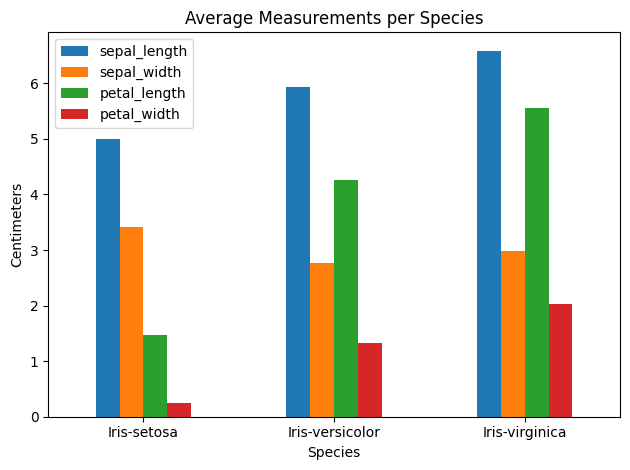

In [9]:
plt.figure(figsize=(8, 5))
df.groupby("species")[["sepal_length", "sepal_width", "petal_length", "petal_width"]].mean().plot(
    kind="bar"
)
plt.title("Average Measurements per Species")
plt.ylabel("Centimeters")
plt.xlabel("Species")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("bar_chart_avg_measurements.png")
plt.show()

# 3. Histogram — distribution of petal length

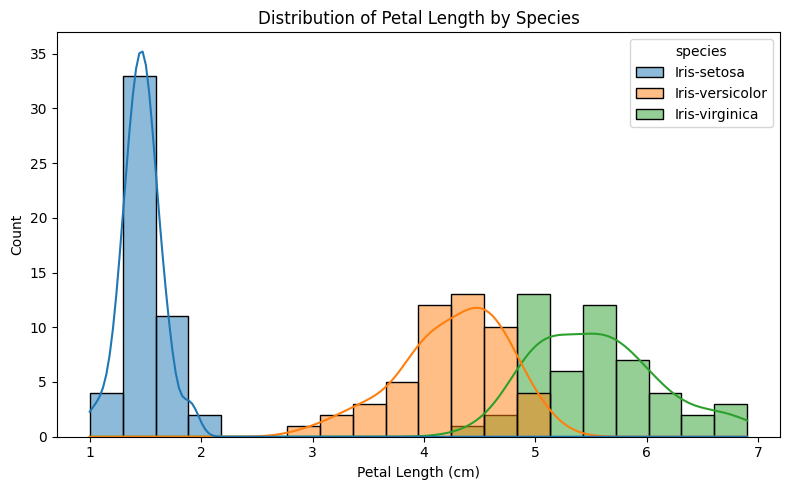

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="petal_length", hue="species", kde=True, bins=20)
plt.title("Distribution of Petal Length by Species")
plt.xlabel("Petal Length (cm)")
plt.tight_layout()
plt.savefig("histogram_petal_length.png")
plt.show()

# 4. Scatter Plot — petal length vs petal width

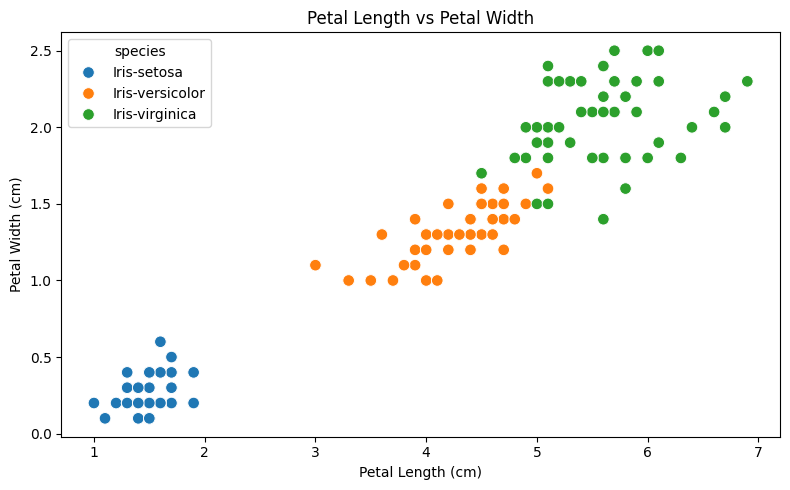

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=70)
plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.savefig("scatter_petal_length_vs_width.png")
plt.show()

# 5. Compare Features — pairplot (all features at once)

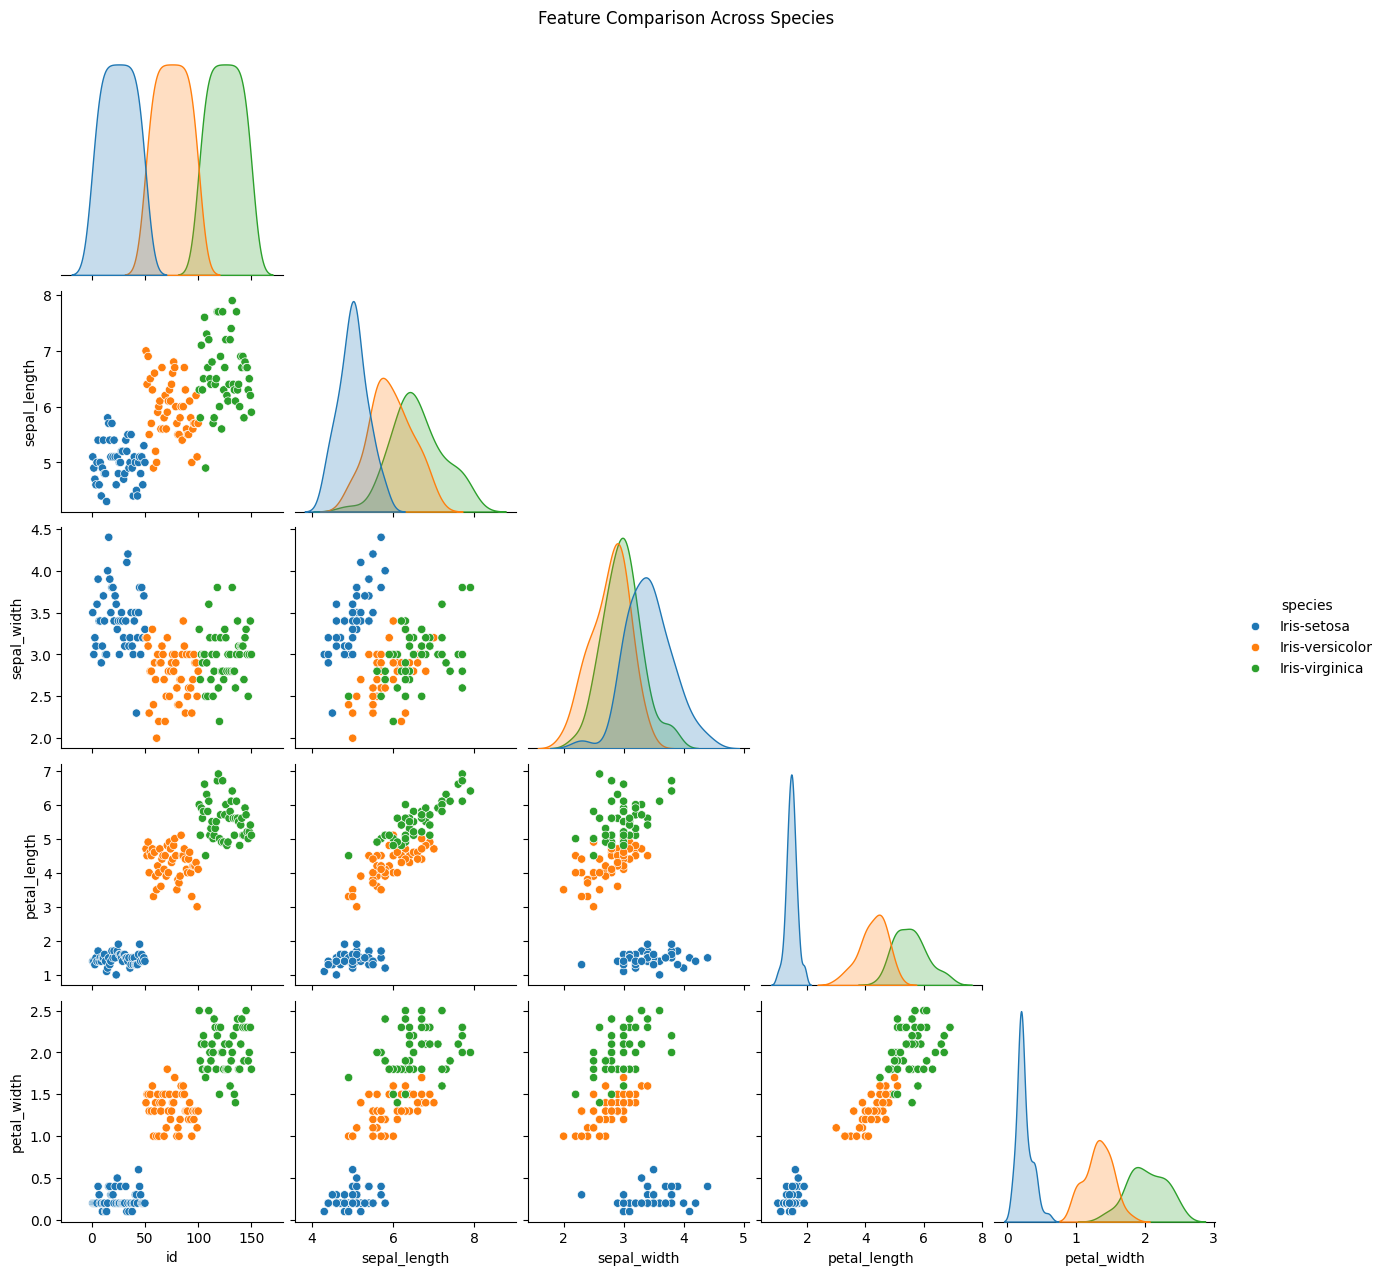

In [13]:
pairplot = sns.pairplot(df, hue="species", corner=True)
pairplot.fig.suptitle("Feature Comparison Across Species", y=1.02)
pairplot.savefig("pairplot_feature_comparison.png")
plt.show()

# 6. Correlation Heatmap (bonus — helps "compare features")

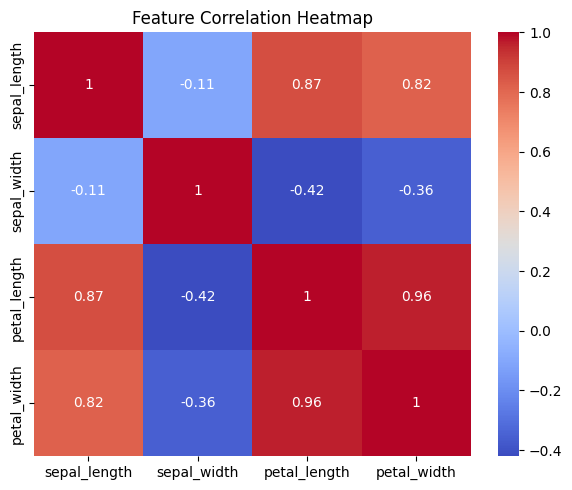

In [14]:
plt.figure(figsize=(6, 5))
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()